In [5]:
%pip install seaborn

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 294.9/294.9 KB 1.6 MB/s eta 0:00:001.9 MB/s eta 0:00:01
Note: you may need to restart the kernel to use updated packages.


In [6]:
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import make_pipeline
from sklearn.metrics import mean_squared_error, r2_score

In [7]:
df=sns.load_dataset('mpg')
df=df[['mpg','displacement']].dropna()
df.head()

,mpg,displacement
0,18.0,307.0
1,15.0,350.0
2,18.0,318.0
3,16.0,304.0
4,17.0,302.0


In [8]:
X=df[['displacement']]
y=df['mpg']
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

In [9]:
linear=LinearRegression()
linear.fit(X_train,y_train)
y_pred=linear.predict(X_test)
print('MSE',mean_squared_error(y_test,y_pred))
print('R2',r2_score(y_test,y_pred))

MSE 18.102543998358946
R2 0.6633114869465596


In [10]:
for d in [2,3,4]:
    model=make_pipeline(PolynomialFeatures(d),LinearRegression())
    model.fit(X_train,y_train)
    pred=model.predict(X_test)
    print(d, mean_squared_error(y_test,pred), r2_score(y_test,pred))

2 15.10735356108076 0.7190189176110284
3 14.943631793037289 0.722063972418907
4 14.961486893912738 0.7217318860908903


/home/mtech/ml_lab/venv/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
/home/mtech/ml_lab/venv/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but PolynomialFeatures was fitted with feature names
  warnings.warn(
/home/mtech/ml_lab/venv/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but PolynomialFeatures was fitted with feature names
  warnings.warn(
/home/mtech/ml_lab/venv/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but PolynomialFeatures was fitted with feature names
  warnings.warn(


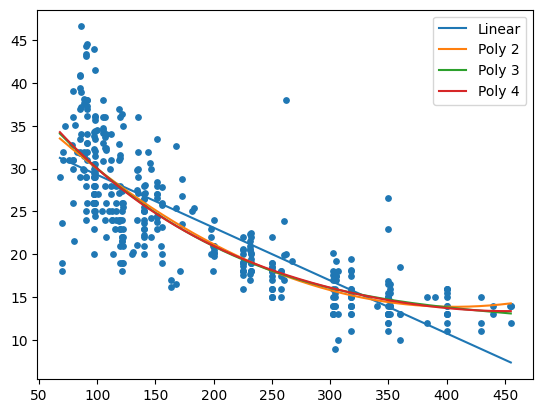

In [11]:
x=np.linspace(X.min().values[0],X.max().values[0],300).reshape(-1,1)
plt.scatter(X,y,s=15)
plt.plot(x,linear.predict(x),label='Linear')
for d in [2,3,4]:
    m=make_pipeline(PolynomialFeatures(d),LinearRegression())
    m.fit(X,y)
    plt.plot(x,m.predict(x),label=f'Poly {d}')
plt.legend()
plt.show()